In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from dvfm.data import sample_checkerboard, sample_moons, sample_spirals
from dvfm.ddpm import DDPMSchedule, ddim_sample, ddpm_loss, ddpm_sample
from dvfm.flow_matching import flow_matching_loss
from dvfm.flow_matching import sample as fm_sample
from dvfm.metrics import energy_distance
from dvfm.models import TimeEmbeddingMLP
from dvfm.train import train_model

datasets = {
    "moons": sample_moons(50_000, seed=0),
    "spirals": sample_spirals(50_000, seed=0),
    "checkerboard": sample_checkerboard(50_000, seed=0),
}
schedule = DDPMSchedule()

CKPT_DIR = Path("../checkpoints")
CKPT_DIR.mkdir(exist_ok=True)
ASSETS_DIR = Path("../assets")

SEEDS = [0, 1, 2]
STEPS = [1, 2, 5, 10, 20, 50, 100]
N = 2000
NUM_TRAIN_STEPS = 10_000

In [2]:
loss_fns = {
    "fm": flow_matching_loss,
    "ddpm": lambda model, x0: ddpm_loss(model, schedule, x0),
}


def ckpt_path(method: str, name: str, seed: int) -> Path:
    # Seed 0 reuses the checkpoints from notebook 05
    suffix = "" if seed == 0 else f"_seed{seed}"
    return CKPT_DIR / f"{method}_{name}{suffix}.pt"


models = {}
for seed in SEEDS:
    for name, data in datasets.items():
        for method, loss_fn in loss_fns.items():
            path = ckpt_path(method, name, seed)
            torch.manual_seed(seed)  # controls initial weights AND training batches
            model = TimeEmbeddingMLP()

            if path.exists():
                model.load_state_dict(torch.load(path))
                model.eval()
                print(f"Loaded {path.name}")
            else:
                print(f"--- Training {method} on {name}, seed {seed} ---")
                train_model(model, data, loss_fn, num_steps=NUM_TRAIN_STEPS, cosine_schedule=True, log_every=0)
                torch.save(model.state_dict(), path)

            models[(method, name, seed)] = model

Loaded fm_moons.pt
Loaded ddpm_moons.pt
Loaded fm_spirals.pt
Loaded ddpm_spirals.pt
Loaded fm_checkerboard.pt
Loaded ddpm_checkerboard.pt
--- Training fm on moons, seed 1 ---
--- Training ddpm on moons, seed 1 ---
--- Training fm on spirals, seed 1 ---
--- Training ddpm on spirals, seed 1 ---
--- Training fm on checkerboard, seed 1 ---
--- Training ddpm on checkerboard, seed 1 ---
--- Training fm on moons, seed 2 ---
--- Training ddpm on moons, seed 2 ---
--- Training fm on spirals, seed 2 ---
--- Training ddpm on spirals, seed 2 ---
--- Training fm on checkerboard, seed 2 ---
--- Training ddpm on checkerboard, seed 2 ---


In [3]:
results = {}

for name, data in datasets.items():
    g = torch.Generator().manual_seed(1)  # same reference set as in notebook 05
    reference = data[torch.randperm(len(data), generator=g)[:N]]
    other_real = data[torch.randperm(len(data), generator=g)[:N]]

    fm_scores, ddim_scores, ddpm_scores = [], [], []
    for seed in SEEDS:
        fm_row, ddim_row = [], []
        for steps in STEPS:
            torch.manual_seed(seed)
            fm_row.append(energy_distance(fm_sample(models[("fm", name, seed)], N, num_steps=steps), reference))
            torch.manual_seed(seed)
            ddim_row.append(energy_distance(ddim_sample(models[("ddpm", name, seed)], schedule, N, num_steps=steps), reference))
        fm_scores.append(fm_row)
        ddim_scores.append(ddim_row)

        torch.manual_seed(seed)
        ddpm_scores.append(energy_distance(ddpm_sample(models[("ddpm", name, seed)], schedule, N), reference))

    results[name] = {
        "baseline": energy_distance(other_real, reference),
        "fm": np.array(fm_scores),      # shape (num_seeds, num_steps)
        "ddim": np.array(ddim_scores),  # shape (num_seeds, num_steps)
        "ddpm": np.array(ddpm_scores),  # shape (num_seeds,)
    }
    print(f"Done: {name}")

Done: moons
Done: spirals
Done: checkerboard


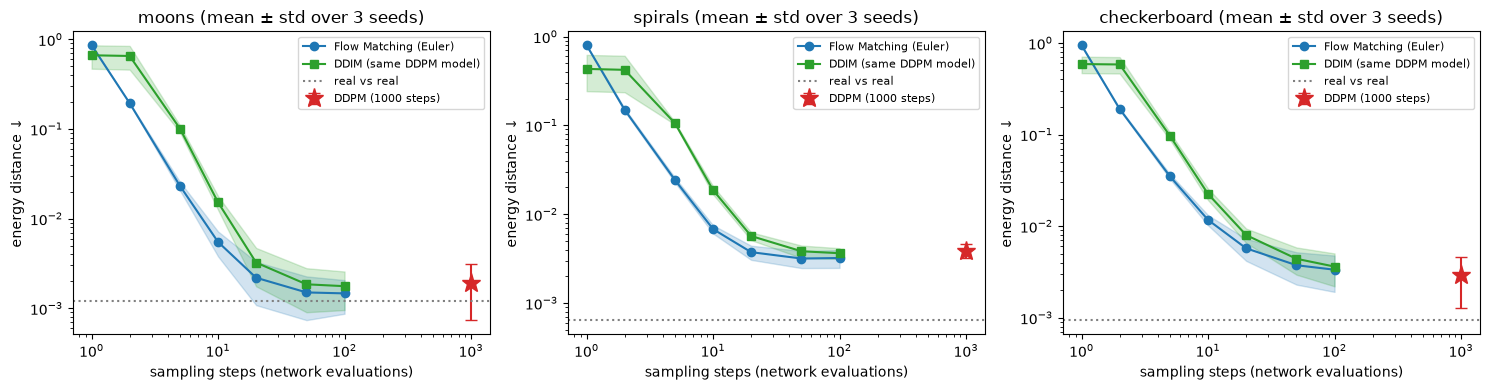

In [4]:
fig, axes = plt.subplots(1, len(results), figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    for key, label, color, marker in [
        ("fm", "Flow Matching (Euler)", "tab:blue", "o"),
        ("ddim", "DDIM (same DDPM model)", "tab:green", "s"),
    ]:
        mean = r[key].mean(axis=0)  # mean over seeds, one value per number of steps
        std = r[key].std(axis=0)
        ax.plot(STEPS, mean, marker=marker, color=color, label=label)
        ax.fill_between(STEPS, mean - std, mean + std, color=color, alpha=0.2)

    ax.errorbar([1000], [r["ddpm"].mean()], yerr=[r["ddpm"].std()], fmt="*", markersize=14,
                color="tab:red", capsize=4, label="DDPM (1000 steps)")
    ax.axhline(r["baseline"], color="gray", linestyle=":", label="real vs real")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("sampling steps (network evaluations)")
    ax.set_ylabel("energy distance ↓")
    ax.set_title(f"{name} (mean ± std over {len(SEEDS)} seeds)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "comparison_quality_vs_steps_seeds.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
table_steps = [5, 10, 20, 100]
idx = [STEPS.index(s) for s in table_steps]

print("| Steps | " + " | ".join(f"{name} (FM / DDIM)" for name in results) + " |")
print("|---|" + "---|" * len(results))
for s, i in zip(table_steps, idx):
    cells = []
    for r in results.values():
        fm = f"{r['fm'][:, i].mean():.4f} ± {r['fm'][:, i].std():.4f}"
        ddim = f"{r['ddim'][:, i].mean():.4f} ± {r['ddim'][:, i].std():.4f}"
        cells.append(f"{fm} / {ddim}")
    print(f"| {s} | " + " | ".join(cells) + " |")

ddpm_cells = [f"{r['ddpm'].mean():.4f} ± {r['ddpm'].std():.4f}" for r in results.values()]
print("| DDPM (1000) | " + " | ".join(ddpm_cells) + " |")

| Steps | moons (FM / DDIM) | spirals (FM / DDIM) | checkerboard (FM / DDIM) |
|---|---|---|---|
| 5 | 0.0232 ± 0.0026 / 0.1009 ± 0.0087 | 0.0243 ± 0.0015 / 0.1057 ± 0.0033 | 0.0349 ± 0.0021 / 0.0965 ± 0.0086 |
| 10 | 0.0055 ± 0.0017 / 0.0152 ± 0.0027 | 0.0068 ± 0.0007 / 0.0187 ± 0.0020 | 0.0117 ± 0.0015 / 0.0224 ± 0.0032 |
| 20 | 0.0022 ± 0.0011 / 0.0032 ± 0.0015 | 0.0037 ± 0.0007 / 0.0057 ± 0.0006 | 0.0057 ± 0.0016 / 0.0080 ± 0.0014 |
| 100 | 0.0015 ± 0.0006 / 0.0018 ± 0.0008 | 0.0032 ± 0.0007 / 0.0036 ± 0.0005 | 0.0033 ± 0.0014 / 0.0036 ± 0.0014 |
| DDPM (1000) | 0.0019 ± 0.0012 | 0.0039 ± 0.0007 | 0.0029 ± 0.0017 |
